<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 2 — Análisis de señales biomédicas con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->

<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Representación temporal, FFT y STFT de señales fisiológicas </font><br>
</div>

---


## Objetivo

En este ejercicio se trabajará con tres registros de la base **NSRDB (Normal Sinus Rhythm Database)** de PhysioNet.

El estudiante deberá:

1. Importar registros fisiológicos desde PhysioNet mediante `wfdb`.
2. Identificar la frecuencia de muestreo y las características básicas de cada señal.
3. Representar las señales en el dominio del tiempo.
4. Analizar su contenido frecuencial mediante la **Transformada Rápida de Fourier (FFT)**.
5. Comparar el espectro antes y después de eliminar la componente DC.
6. Analizar cómo cambia el contenido frecuencial a lo largo del tiempo mediante **STFT** y espectrogramas.
7. Comparar los tres registros y formular conclusiones.

> **Idea central:** una señal puede estudiarse desde el dominio temporal, el dominio frecuencial y el dominio tiempo-frecuencia.


## 1. Introducción

Una señal biomédica contiene información que puede observarse desde diferentes perspectivas.

### Dominio temporal

Permite estudiar cómo cambia la amplitud de la señal con el tiempo:
<!-- Este es un comentario y no aparecerá visualmente en Colab $$
t[n]=\frac{n}{f_s}
$$   \[
t[n]=\frac{n}{f_s}
\]   -->

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio frecuencial

La FFT permite analizar qué componentes de frecuencia están presentes en una señal:

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio tiempo-frecuencia

La STFT permite observar cómo evoluciona el contenido frecuencial a lo largo del tiempo.

En este ejercicio se analizarán tres registros:

- `16265`
- `16272`
- `16420`

pertenecientes a la base `nsrdb`.


## 2. Parámetros del ejercicio

Cada registro se cargará utilizando las primeras **10 segundos** de información.

| Parámetro | Valor |
|---|---|
| Base de datos | `nsrdb` |
| Registro 1 | `16265` |
| Registro 2 | `16272` |
| Registro 3 | `16420` |
| Muestras | `3600` por registro |
| Canal analizado | `0` |

### Pregunta inicial

Antes de ejecutar el notebook:

**¿Qué diferencia espera encontrar entre analizar una señal en el dominio del tiempo y analizarla en el dominio de la frecuencia?**

La diferencia principal rádica en que para el dominio del tiempo nos devolverá la forma de la señal y nos sirveria medir intervalos. Por otro lado, el dominio de frecuencia encontraré los picos de energía de la señal y me permitirá identificar los componentes frecuenciales de la señal.

In [34]:
# ============================================
# PARÁMETROS
# ============================================

DATABASE = "nsrdb"

RECORDS = ["16265", "16272", "16420"]

SAMPFROM = 0
SAMPLING_POINTS = 3600

CHANNEL = 0

print("Parámetros del ejercicio")
print("=" * 45)
print(f"Base de datos       : {DATABASE}")
print(f"Registros           : {RECORDS}")
print(f"Muestras por señal  : {SAMPLING_POINTS}")
print(f"Canal seleccionado  : {CHANNEL}")


Parámetros del ejercicio
Base de datos       : nsrdb
Registros           : ['16265', '16272', '16420']
Muestras por señal  : 3600
Canal seleccionado  : 0


## 3. Instalación e importación de librerías

Se utilizarán:

- **WFDB:** acceso a registros fisiológicos de PhysioNet.
- **NumPy:** procesamiento numérico y FFT.
- **SciPy:** cálculo de la STFT.
- **Matplotlib:** visualización.


In [35]:
# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!pip install -q wfdb scipy numpy matplotlib


In [36]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 4. Cargar los tres registros desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

El parámetro `pn_dir` permite indicar la base de datos disponible en PhysioNet.

También se intentará cargar la anotación `atr` de cada registro para dejar disponible la información de anotaciones cuando exista.


In [37]:
# ============================================
# CARGAR LOS TRES REGISTROS
# ============================================

records_data = {}

for record_name in RECORDS:
    record = wfdb.rdrecord(
        record_name,
        pn_dir=DATABASE,
        sampfrom=SAMPFROM,
        sampto=SAMPFROM + SAMPLING_POINTS
    )

    records_data[record_name] = record

    print(f"Registro {record_name} cargado correctamente.")


Registro 16265 cargado correctamente.
Registro 16272 cargado correctamente.
Registro 16420 cargado correctamente.


In [38]:
# ============================================
# CARGAR ANOTACIONES
# ============================================

annotations = {}

for record_name in RECORDS:
    try:
        annotation = wfdb.rdann(
            record_name,
            "atr",
            pn_dir=DATABASE,
            sampfrom=SAMPFROM,
            sampto=SAMPFROM + SAMPLING_POINTS
        )
        annotations[record_name] = annotation
        print(f"Anotaciones del registro {record_name}: {len(annotation.sample)}")
    except Exception as e:
        annotations[record_name] = None
        print(f"No fue posible cargar anotaciones para {record_name}: {e}")


Anotaciones del registro 16265: 45
Anotaciones del registro 16272: 31
Anotaciones del registro 16420: 44


## 5. Explorar la información de los registros

Antes de realizar cualquier análisis es importante conocer:

- frecuencia de muestreo;
- número de muestras;
- número de canales;
- nombre de los canales;
- unidades de medida.



In [39]:
# ============================================
# INFORMACIÓN DE LOS REGISTROS
# ============================================

for record_name, record in records_data.items():
    duration = record.sig_len / record.fs

    print("=" * 60)
    print(f"REGISTRO: {record_name}")
    print("=" * 60)
    print(f"Frecuencia de muestreo : {record.fs} Hz")
    print(f"Número de muestras     : {record.sig_len}")
    print(f"Número de canales      : {record.n_sig}")
    print(f"Canales                : {record.sig_name}")
    print(f"Unidades               : {record.units}")
    print(f"Duración analizada     : {duration:.2f} s")


REGISTRO: 16265
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16272
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16420
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s


### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo de cada registro?
  Para los 3 registros es de 128 Hz
2. ¿Los tres registros tienen la misma frecuencia de muestreo?
Si
3. ¿Cuántos canales posee cada registro? 2 canales
4. ¿Qué señal corresponde al canal `0`? Corresponde a ECG1
5. ¿Cuántas muestras contiene cada registro? 3600 muestras
6. ¿Por qué `3600` muestras corresponden aproximadamente a 10 segundos cuando `fs = 360 Hz`? Hay una relación entre el número de muestras , la fs y el tiempo la cual es : t = N/fs  si reemplazamos 10 = 3600 / fs , entonces fs = 360 Hz


# 6. Extracción de las señales y construcción del eje temporal

Las muestras se encuentran en:

```python
record.p_signal
```

La estructura tiene la forma:

```text
(muestras, canales)
```

Por ello, para seleccionar el canal indicado:

```python
x = record.p_signal[:, CHANNEL]
```

El eje temporal se construye mediante:

\[
t[n]=rac{n}{f_s}
\]


In [40]:
# ============================================
# EXTRAER SEÑALES Y EJES TEMPORALES
# ============================================

signals = {}
times = {}
sampling_rates = {}

for record_name, record in records_data.items():
    x = record.p_signal[:, CHANNEL]
    fs = record.fs

    signals[record_name] = x
    sampling_rates[record_name] = fs
    times[record_name] = np.arange(len(x)) / fs

    print(
        f"{record_name}: "
        f"{len(x)} muestras, "
        f"fs = {fs} Hz, "
        f"canal = {record.sig_name[CHANNEL]}"
    )


16265: 3600 muestras, fs = 128 Hz, canal = ECG1
16272: 3600 muestras, fs = 128 Hz, canal = ECG1
16420: 3600 muestras, fs = 128 Hz, canal = ECG1


# 7. Gráficas — Amplitud vs. tiempo

Primero observaremos las tres señales en el dominio temporal.

### ¿Qué debemos observar?

- amplitud;
- duración;
- forma de onda;
- periodicidad;
- cambios o eventos particulares;
- diferencias entre registros.


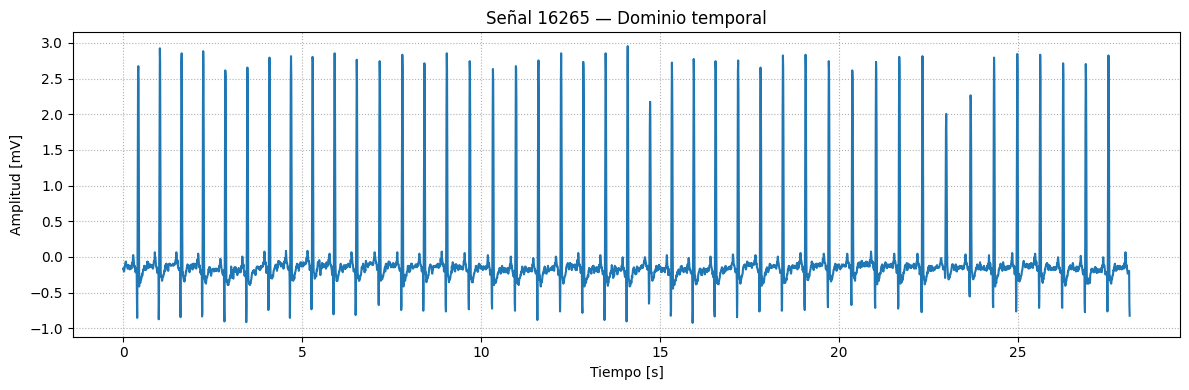

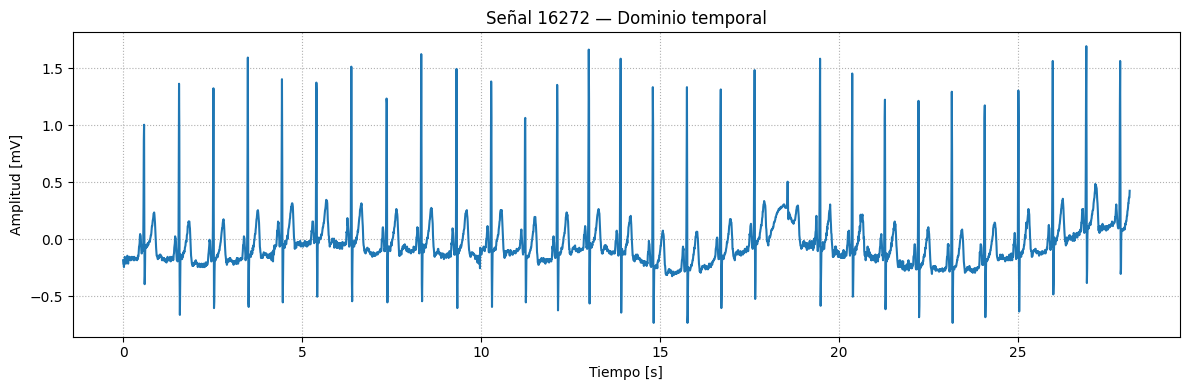

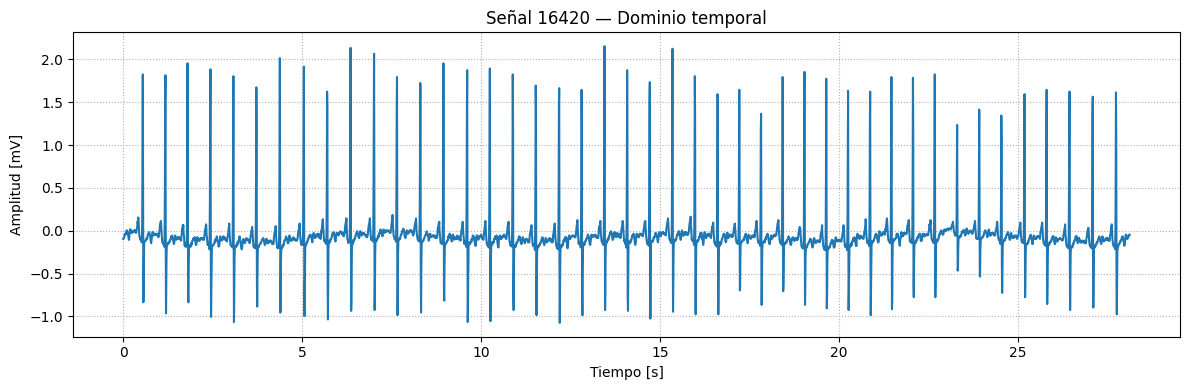

In [41]:
# ============================================
# DOMINIO TEMPORAL — TRES REGISTROS
# ============================================

for record_name in RECORDS:
    record = records_data[record_name]
    x = signals[record_name]
    t = times[record_name]

    plt.figure(figsize=(12, 4))
    plt.plot(t, x)

    plt.title(f"Señal {record_name} — Dominio temporal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


### Preguntas de análisis 2

1. ¿Las tres señales presentan una morfología similar?
Sí presentan una morfologia similar que concuerda con ECG.
2. ¿Cuál presenta mayor variación de amplitud?
La señal 16272 ya que presenta una oscilación y se sale con diferencia del eje 0.
3. ¿Se observan patrones periódicos?
Sí, en las 3 señales se observan patrones periódicos , principalmente marcado por la repetición de grandes picos que vendrían a ser el pico R de una señal ECG.
4. ¿Se identifican eventos o cambios particulares?
Sí , en la señal 16272 se puede ver  aproximadamente entre el segundo 18 y 19 se pierde la forma que se estaba conservando de manera periodica.
5. ¿Qué información puede obtenerse fácilmente desde la gráfica temporal?
La amplitud en mV, el tiempo en s , la morfología de la señal y la periodicidad de está.


# 8. Transformada Rápida de Fourier (FFT)

La FFT permite transformar una señal del dominio temporal al dominio frecuencial.

Antes de calcularla consideraremos dos casos:

### Caso A — señal original

\[
x[n]
\]

### Caso B — señal sin componente DC

\[
x_{AC}[n]=x[n]-\overline{x}
\]

La componente DC está asociada con el valor medio de la señal y aparece alrededor de **0 Hz** en el espectro.

Para comparar correctamente los registros utilizaremos el espectro de un solo lado, correspondiente a las frecuencias positivas.


In [42]:
# ============================================
# FUNCIÓN PARA CALCULAR FFT
# ============================================

def calculate_fft(x, fs):
    n = len(x)

    x_dc_removed = x - np.mean(x)

    spectrum_original = np.fft.rfft(x)
    spectrum_ac = np.fft.rfft(x_dc_removed)

    frequencies = np.fft.rfftfreq(n, d=1/fs)

    magnitude_original = np.abs(spectrum_original)
    magnitude_ac = np.abs(spectrum_ac)

    return (
        frequencies,
        magnitude_original,
        magnitude_ac,
        x_dc_removed
    )


In [43]:
# ============================================
# CALCULAR FFT PARA LOS TRES REGISTROS
# ============================================

fft_data = {}

for record_name in RECORDS:
    fs = sampling_rates[record_name]
    x = signals[record_name]

    frequencies, magnitude_original, magnitude_ac, x_dc_removed = calculate_fft(
        x, fs
    )

    fft_data[record_name] = {
        "frequencies": frequencies,
        "magnitude_original": magnitude_original,
        "magnitude_ac": magnitude_ac,
        "signal_ac": x_dc_removed
    }

    print(
        f"{record_name}: "
        f"frecuencia máxima analizada = {frequencies[-1]:.2f} Hz"
    )


16265: frecuencia máxima analizada = 64.00 Hz
16272: frecuencia máxima analizada = 64.00 Hz
16420: frecuencia máxima analizada = 64.00 Hz


## 9. FFT de la señal original y de la señal sin DC

Para cada registro se mostrarán dos espectros:

1. **FFT con componente DC**
2. **FFT después de eliminar la media**

El objetivo es observar cómo cambia el espectro al retirar la componente de frecuencia cero.


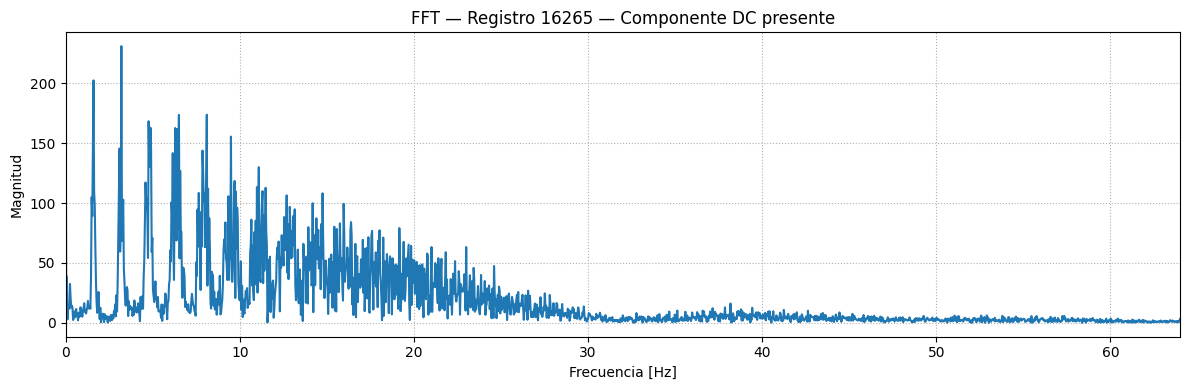

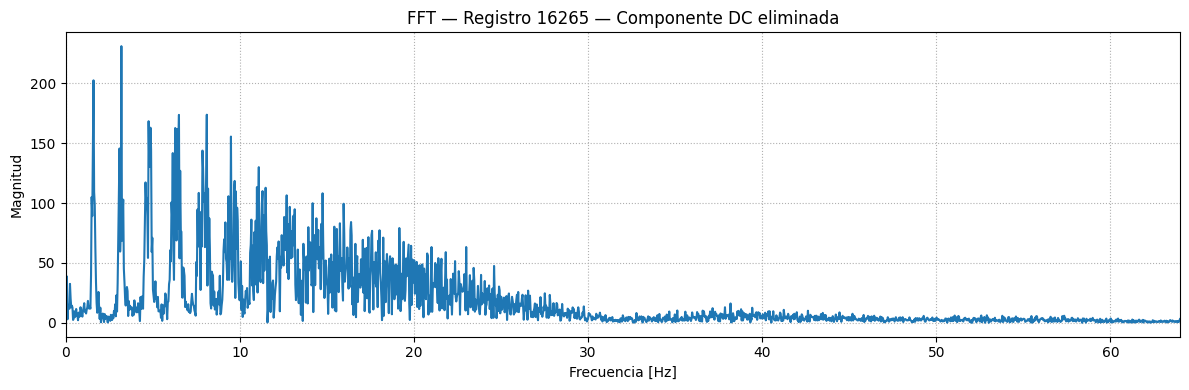

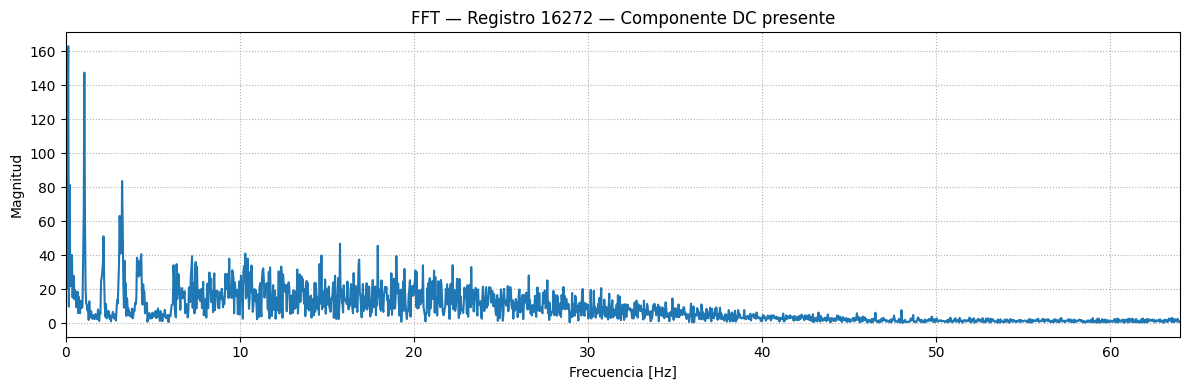

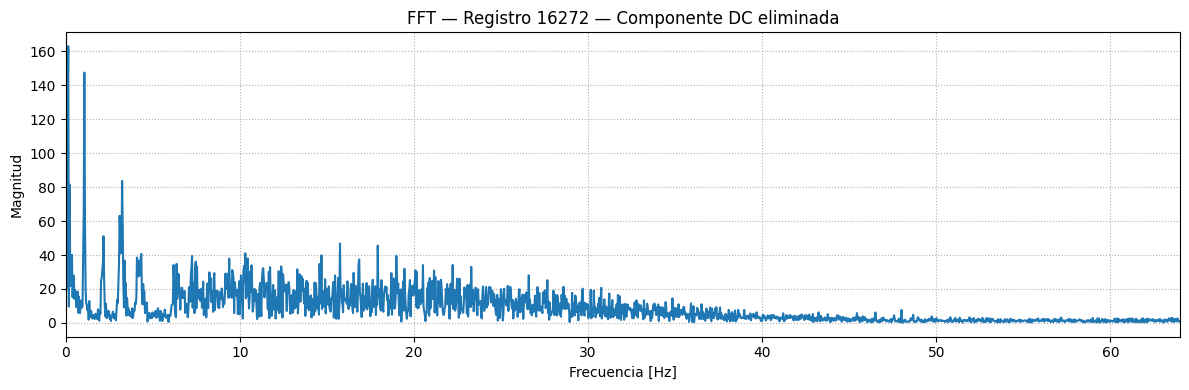

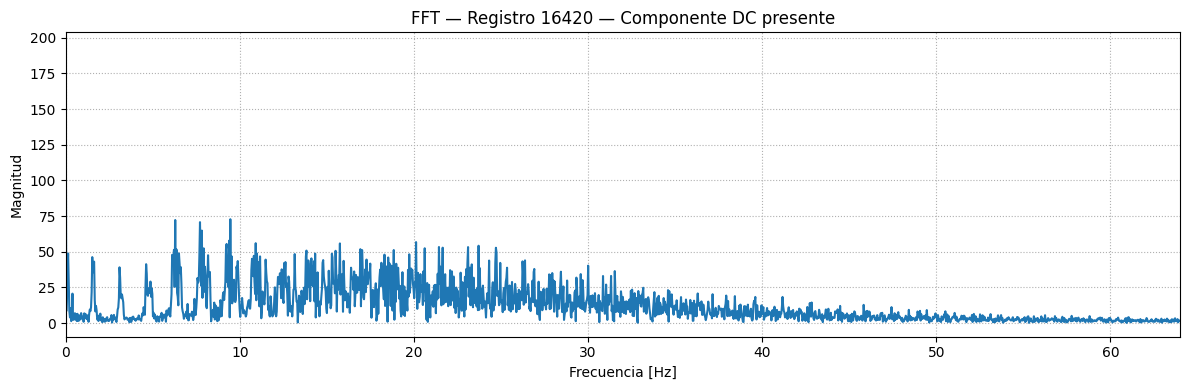

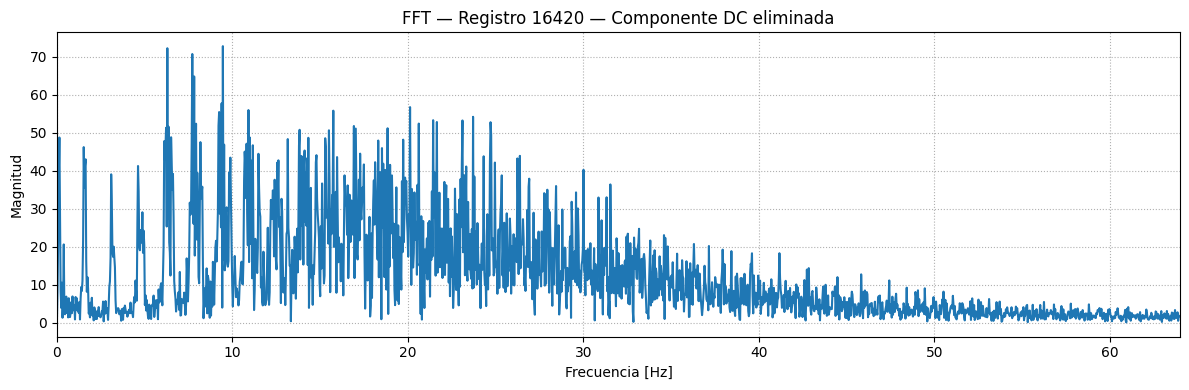

In [44]:
# ============================================
# FFT — COMPARACIÓN CON Y SIN DC
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]
    f = data["frequencies"]

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_original"])
    plt.title(f"FFT — Registro {record_name} — Componente DC presente")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_ac"])
    plt.title(f"FFT — Registro {record_name} — Componente DC eliminada")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


### Preguntas de análisis 3

1. ¿Qué ocurre con el componente cercano a 0 Hz después de eliminar la media?
En el registro 16420 se puede observar que el componente DC en 0 Hz se atenúa , de modo que la grafica se ajusta hasta la magnitud de 70 , ya se eliminó la componente DC.
2. ¿Qué diferencias observa entre los espectros de los tres registros?
El registro 16525 es que presenta los picos con mayor magnitud , luego le sigue el  16272 con dos picos de 160 y 140. Por último el registro 16420 , es el que tiene la magnitud mas baja de 70
3. ¿En qué intervalo de frecuencias se concentra la mayor parte de la energía?
Principalmente o aproximadamente entre 0.5 a 35 Hz.
4. ¿Por qué la FFT no conserva directamente la información temporal?
 Por la FFT integra la señal a lo largo de todo el segmento de tiempo para calcular el promedio de energía de cada frecuencia. En este proceso, condensa los 28 segundos de nuestras señales en un solo valor por frecuencia.
5. ¿Qué ventaja ofrece observar una señal en el dominio frecuencial?
Nos permité identificar la energía de la frecuencia de la señal e identificar los artefactos de interés . Esto es algo clave para filtrar ruido sin afectar al resto de la señal


# 10. Identificación de la frecuencia dominante

Como ejercicio adicional, podemos localizar la frecuencia con mayor magnitud después de retirar la componente DC.

> **Importante:** la frecuencia dominante encontrada mediante FFT no debe interpretarse automáticamente como una frecuencia fisiológica específica. Es necesario considerar el tipo de señal, el procesamiento aplicado y el contexto del registro.


In [45]:
# ============================================
# FRECUENCIA DOMINANTE
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]

    # Ignorar 0 Hz para evitar seleccionar nuevamente la componente DC
    idx = np.argmax(data["magnitude_ac"][1:]) + 1

    dominant_frequency = data["frequencies"][idx]
    dominant_magnitude = data["magnitude_ac"][idx]

    print(
        f"Registro {record_name}: "
        f"frecuencia dominante = {dominant_frequency:.3f} Hz, "
        f"magnitud = {dominant_magnitude:.3f}"
    )


Registro 16265: frecuencia dominante = 3.200 Hz, magnitud = 230.841
Registro 16272: frecuencia dominante = 0.142 Hz, magnitud = 163.096
Registro 16420: frecuencia dominante = 9.458 Hz, magnitud = 72.800


# 11. STFT — Transformada de Fourier de Tiempo Corto

La FFT proporciona información sobre el contenido frecuencial global de una señal.

Sin embargo, si queremos saber **cuándo** aparecen determinadas componentes de frecuencia necesitamos una representación tiempo-frecuencia.

La STFT divide la señal en ventanas y calcula una FFT para cada ventana.

Conceptualmente:

```text
Señal completa
      ↓
┌────────┬────────┬────────┬────────┐
│ Ventana│ Ventana│ Ventana│ Ventana│
└────────┴────────┴────────┴────────┘
      ↓
     FFT para cada ventana
      ↓
Espectrograma
```

El tamaño de ventana determina un compromiso entre resolución temporal y resolución frecuencial:

- ventana pequeña → mejor resolución temporal;
- ventana grande → mejor resolución frecuencial.


In [46]:
# ============================================
# STFT — FUNCIÓN DE CÁLCULO
# ============================================

def calculate_stft(x, fs, nperseg=256):
    f, t, zxx = signal.stft(
        x,
        fs=fs,
        nperseg=nperseg
    )

    return f, t, zxx


## 12. STFT de los registros

Para los registros 1 y 3 utilizaremos una ventana de 256 muestras.

Para el registro 2 utilizaremos una ventana más pequeña de 32 muestras, siguiendo el esquema del ejercicio de referencia, con el propósito de conservar mejor eventos verticales/localizados en el tiempo.

### Parámetro importante

```python
nperseg
```

representa el número de muestras de cada ventana.


In [47]:
# ============================================
# CALCULAR STFT
# ============================================

WINDOWS = {
    "16265": 256,
    "16272": 32,
    "16420": 256
}

stft_data = {}

for record_name in RECORDS:
    x = fft_data[record_name]["signal_ac"]
    fs = sampling_rates[record_name]
    nperseg = WINDOWS[record_name]

    f, t, zxx = calculate_stft(
        x,
        fs,
        nperseg=nperseg
    )

    stft_data[record_name] = {
        "f": f,
        "t": t,
        "zxx": zxx
    }

    print(
        f"{record_name}: "
        f"nperseg = {nperseg}, "
        f"ventanas calculadas = {len(t)}"
    )


16265: nperseg = 256, ventanas calculadas = 30
16272: nperseg = 32, ventanas calculadas = 226
16420: nperseg = 256, ventanas calculadas = 30


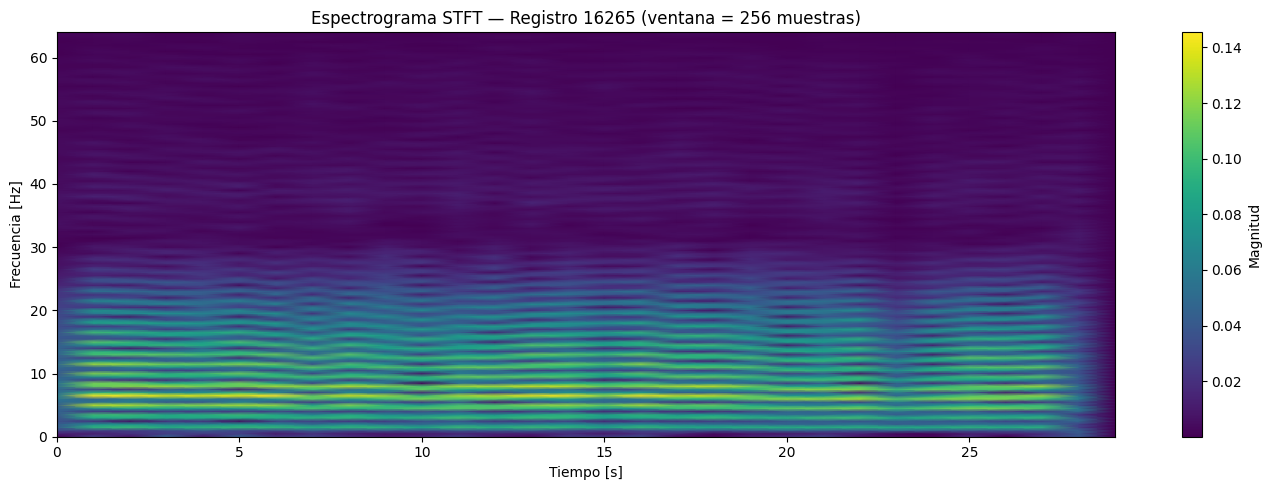

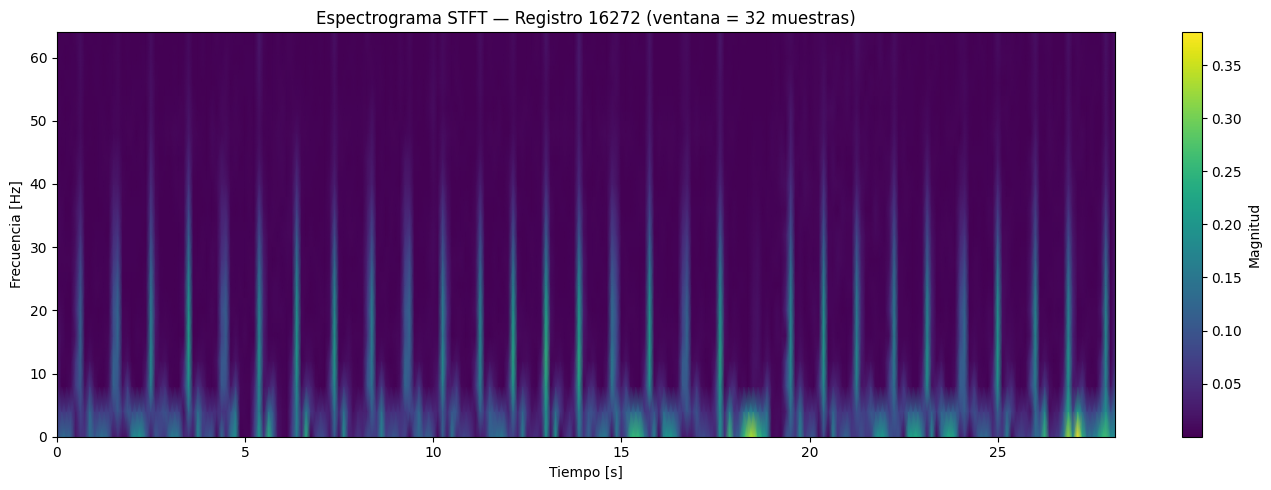

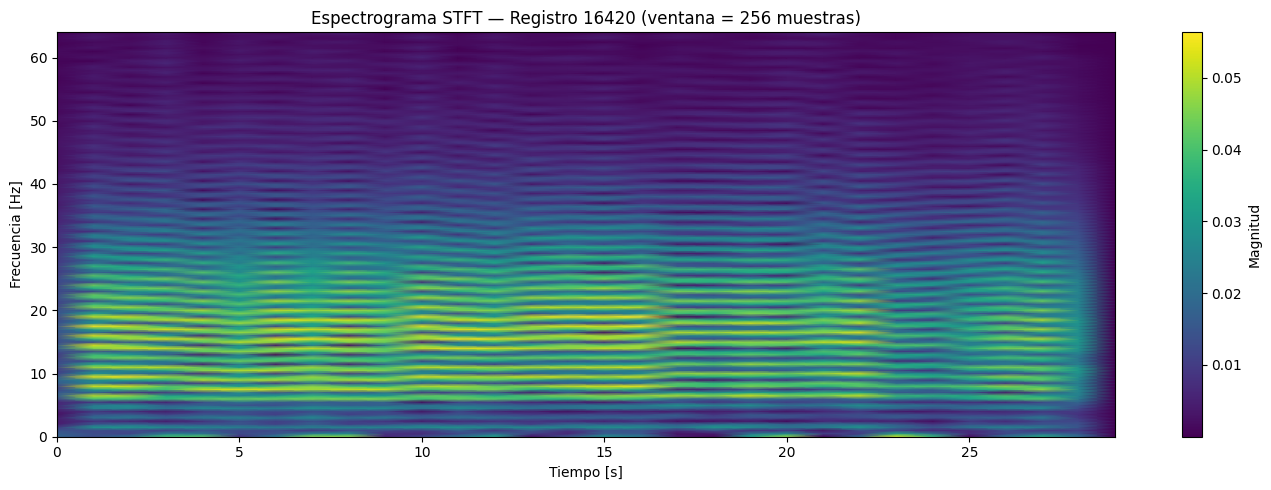

In [48]:
# ============================================
# ESPECTROGRAMAS STFT
# ============================================

for record_name in RECORDS:
    data = stft_data[record_name]

    f = data["f"]
    t = data["t"]
    zxx = data["zxx"]

    plt.figure(figsize=(14, 5))

    plt.pcolormesh(
        t,
        f,
        np.abs(zxx),
        shading="gouraud"
    )

    plt.title(
        f"Espectrograma STFT — Registro {record_name} "
        f"(ventana = {WINDOWS[record_name]} muestras)"
    )
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.colorbar(label="Magnitud")

    plt.tight_layout()
    plt.show()


### Preguntas de análisis 4

1. ¿Qué información adicional proporciona la STFT respecto a la FFT?
A diferencia esta también proporciona la información temporal en segundos.
2. ¿En qué momentos se observan cambios de energía?
En el registro 16420 se observa un claro cambio de energía aproximadamente a los 23 segundos por que hay una reducción en la intensidad de color.
3. ¿Qué diferencias observa entre los tres espectrogramas?
El registro 16272 muestra bandas verticales bien definidas lo que se conoce como una buena resolución temporal , mientras que los otros muestras bandas horizontales estas al tener una ventana de 256 tienen una resolución frecuencial pero baja temporal.
4. ¿Por qué el registro `16272` utiliza una ventana de 32 muestras?
Se utiliza una ventana pequeña deliberadamente para priorizar la resolución temporal. Haciendo esto permite ver las lineas claras verticales, nos permite ver la señal con claridad.
5. ¿Qué podría ocurrir si se utiliza una ventana demasiado grande?
Se perdería la resolución temporal , entonces ya no podría saber cuando ocurre exactamente un evento.
6. ¿Qué podría ocurrir si se utiliza una ventana demasiado pequeña?
Se perdería la resolución frecuencial por lo que no podría identificar las frecuencias de las que estaria compuesta la señal.


# 13. Comparación de los tres registros

Complete la siguiente tabla a partir de los resultados obtenidos.

| Característica | Registro 16265 | Registro 16272 | Registro 16420 |
|---|---|---|---|
| Frecuencia de muestreo | 128 Hz | 128 Hz | 128 Hz |
| Número de muestras | 3600 | 3600 | 3600 |
| Número de canales | 2 | 2 | 2 |
| Amplitud observada | ~ -1.0 a 3.0 mV | ~ -0.7 a 1.7 mV | ~ -1.0 a 2.1 mV |
| Componente DC | 211.39 (Alta) | 163.49 (Media) | 194.10 (Alta) |
| Frecuencias dominantes | 3.200 Hz | 0.142 Hz | 9.458 Hz |
| Comportamiento STFT | Bandas horizontales claras | Picos verticales definidos | Bandas horizontales tenues |
| Observaciones | Ritmo muy estable | Alta variabilidad temporal | Pérdida de energía al final |

### Discusión

Explique:

- **Qué registro presenta mayor variabilidad:**

  El registro **16272** muestra la mayor variabilidad, especialmente visible en el dominio temporal donde la línea base oscila significativamente.
- **Qué diferencias aparecen en el dominio temporal:**

  Aunque todos son ECG, el 16265 es el más regular, mientras que el 16272 tiene una arritmia o cambio morfológico visible cerca del segundo 18.
- **Qué diferencias aparecen en el dominio frecuencial:**

  El 16265 tiene picos de potencia muy concentrados en bajas frecuencias. El 16420 tiene una potencia mucho más baja y distribuida.
- **Qué información adicional aporta la STFT:**

  Permite ver cambios dinámicos, como la caída de intensidad en el registro 16420 que la FFT normal no detectaría como un evento puntual.
- **Cómo influye el tamaño de ventana:**

  En el 16272, la ventana pequeña (32) permitió separar cada latido individualmente en el espectrograma (resolución temporal).

# 14. Ejercicios propuestos

## Ejercicio 2.1 — Cambiar el segmento temporal

Modifique:

```python
SAMPFROM = 0
```

para analizar otra región del registro.

Por ejemplo, pruebe con un segmento posterior del registro.

### Analice

1. ¿La morfología cambia?
Se mantiene de manera general
2. ¿El espectro cambia?
Hay un leve cambio en la magnitud
3. ¿La STFT muestra nuevos eventos?
Aumento un poco la intensidad pero realmente son igual
4. ¿Qué diferencias encuentra respecto al segmento original?
Principalmente hubo un aumento en la amplitud y la intensidad
---

## Ejercicio 2.2 — Cambiar el tamaño de ventana

Para el registro `16272`, compare:

```python
nperseg = 32
```

con:

```python
nperseg = 128
```

y:

```python
nperseg = 256
```

### Responda

1. ¿Cuál permite observar mejor los eventos temporales?
A menor ventana mejor resolución temporal por lo tanto nperseg = 32 es la que permite observar mejor este tipo de eventos.
2. ¿Cuál proporciona mayor detalle en frecuencia?
A mayor ventana mejor resolución frecuencial por lo tanto nperseg = 256 es la que permite observar mejor este tipo de eventos.
3. ¿Cuál considera más apropiada para este registro? Justifique.
En este caso al ser un registro de un ECG lo mejor seria usar ventana pequeña entonces la de 32 pienso que es la más apropiada.

---

## Ejercicio 2.3 — Comparación FFT vs. STFT

Explique con sus propias palabras:

> ¿Por qué una FFT global puede ocultar cuándo ocurre un determinado evento, mientras que una STFT puede localizarlo temporalmente?
La FFT toma toda la señal y hace un promedio de cada frecuencia, lo junta todo dejando de lado el tiempo . Mientras que las STFT corta en ventanas la señal y luego aplica la transformada a cada una , perimitiendo ubicar las instantes o intervalos de tiempo.


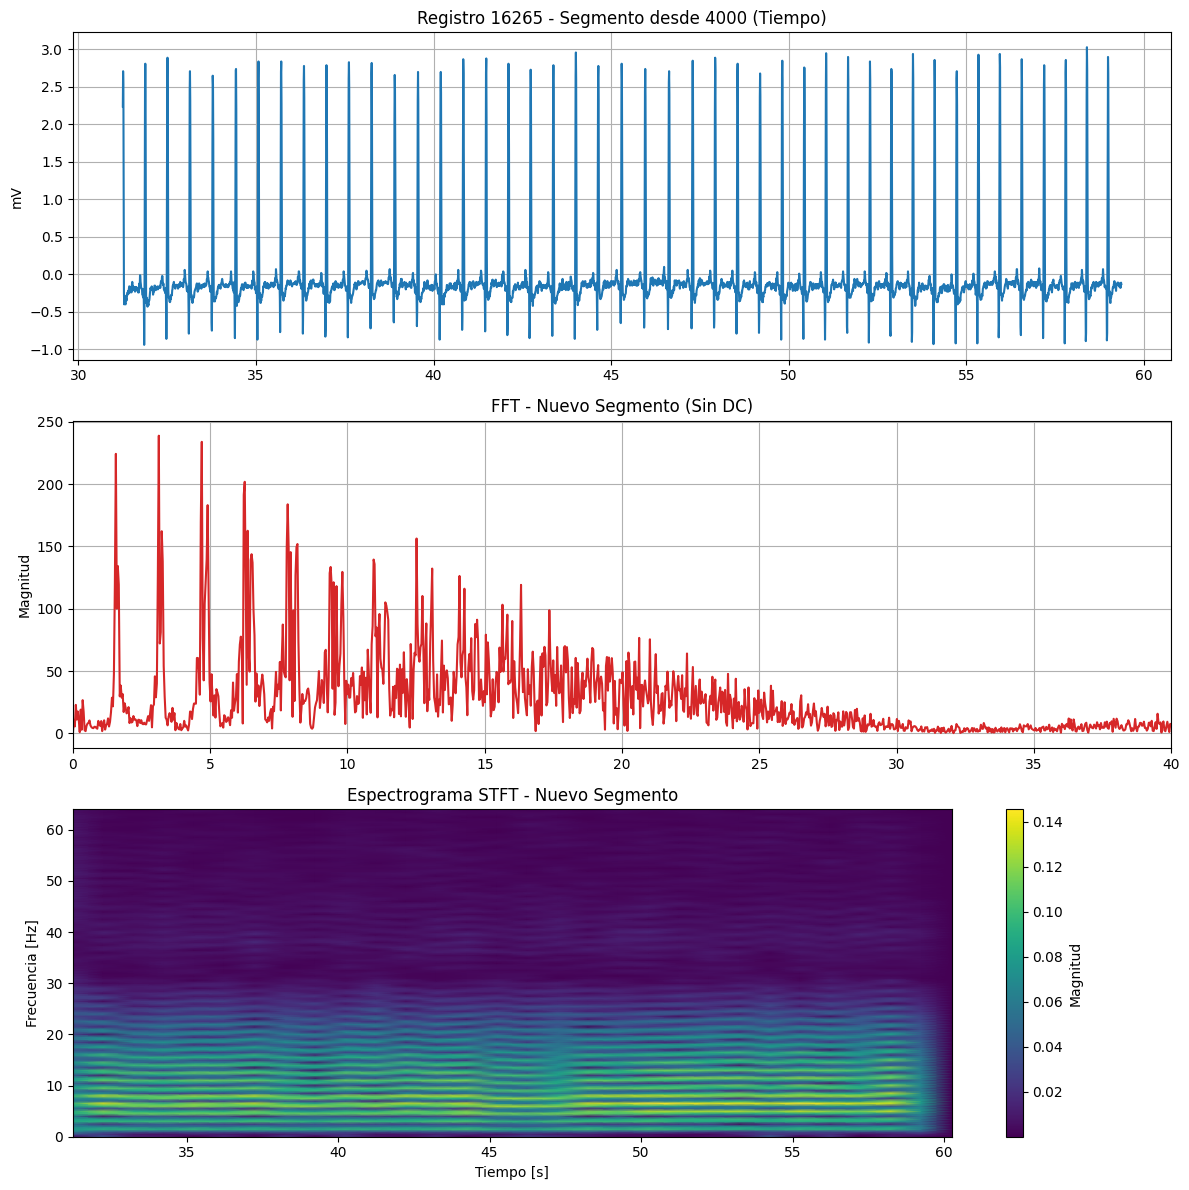

In [49]:
import numpy as np                                      # Importamos numpy para el manejo de vectores y matrices
import matplotlib.pyplot as plt                        # Importamos pyplot para la creación de gráficas
import wfdb                                            # Importamos wfdb para interactuar con la base de datos PhysioNet
from scipy import signal                               # Importamos el módulo de señales de scipy para la STFT

# 1. Definir nuevo segmento (Ejercicio 2.1)
SAMPFROM_NEW = 4000                                    # Modificado: Punto de inicio en la muestra 4000
SAMPLING_POINTS = 3600                                 # Mantenemos la ventana de 3600 muestras (~28s)
RECORD_NAME = "16265"                                  # Nombre del registro de la base NSRDB

# 2. Cargar nuevo segmento
# Leemos el registro desde PhysioNet especificando el rango de muestras
record_new = wfdb.rdrecord(RECORD_NAME, pn_dir="nsrdb", sampfrom=SAMPFROM_NEW, sampto=SAMPFROM_NEW + SAMPLING_POINTS)
x_new = record_new.p_signal[:, 0]                      # Extraemos el primer canal (ECG1) de la señal
fs = record_new.fs                                     # Obtenemos la frecuencia de muestreo del registro
t_new = (np.arange(len(x_new)) + SAMPFROM_NEW) / fs    # Creamos el eje de tiempo ajustado al punto de inicio

# 3. Procesamiento (FFT y STFT)
x_ac_new = x_new - np.mean(x_new)                      # Eliminamos la componente DC restando el valor promedio
freqs_new = np.fft.rfftfreq(len(x_new), d=1/fs)        # Calculamos el eje de frecuencias para la FFT
mag_ac_new = np.abs(np.fft.rfft(x_ac_new))             # Calculamos la magnitud de la FFT de la señal sin DC

# Calculamos la STFT con una ventana de 256 muestras
f_stft, t_stft, zxx_new = signal.stft(x_ac_new, fs=fs, nperseg=256)

# 4. Visualización
fig, axs = plt.subplots(3, 1, figsize=(12, 12))        # Creamos una figura con 3 sub-gráficas verticales

# Gráfica en el Dominio del Tiempo
axs[0].plot(t_new, x_new, color='tab:blue')            # Dibujamos la señal original vs tiempo
axs[0].set_title(f"Registro {RECORD_NAME} - Segmento desde {SAMPFROM_NEW} (Tiempo)")
axs[0].set_ylabel("mV")                                # Unidades en milivoltios
axs[0].grid(True)

# Gráfica en el Dominio de la Frecuencia (FFT)
axs[1].plot(freqs_new, mag_ac_new, color='tab:red')    # Dibujamos la magnitud vs frecuencia
axs[1].set_title("FFT - Nuevo Segmento (Sin DC)")
axs[1].set_xlim(0, 40)                                 # Limitamos a 40Hz para ver mejor las frecuencias de interés
axs[1].set_ylabel("Magnitud")
axs[1].grid(True)

# Gráfica de Tiempo-Frecuencia (Espectrograma STFT)
# Usamos pcolormesh para mostrar la densidad de energía en colores
im = axs[2].pcolormesh(t_stft + (SAMPFROM_NEW/fs), f_stft, np.abs(zxx_new), shading='gouraud')
axs[2].set_title("Espectrograma STFT - Nuevo Segmento")
axs[2].set_xlabel("Tiempo [s]")
axs[2].set_ylabel("Frecuencia [Hz]")
fig.colorbar(im, ax=axs[2], label="Magnitud")

plt.tight_layout()
plt.show()

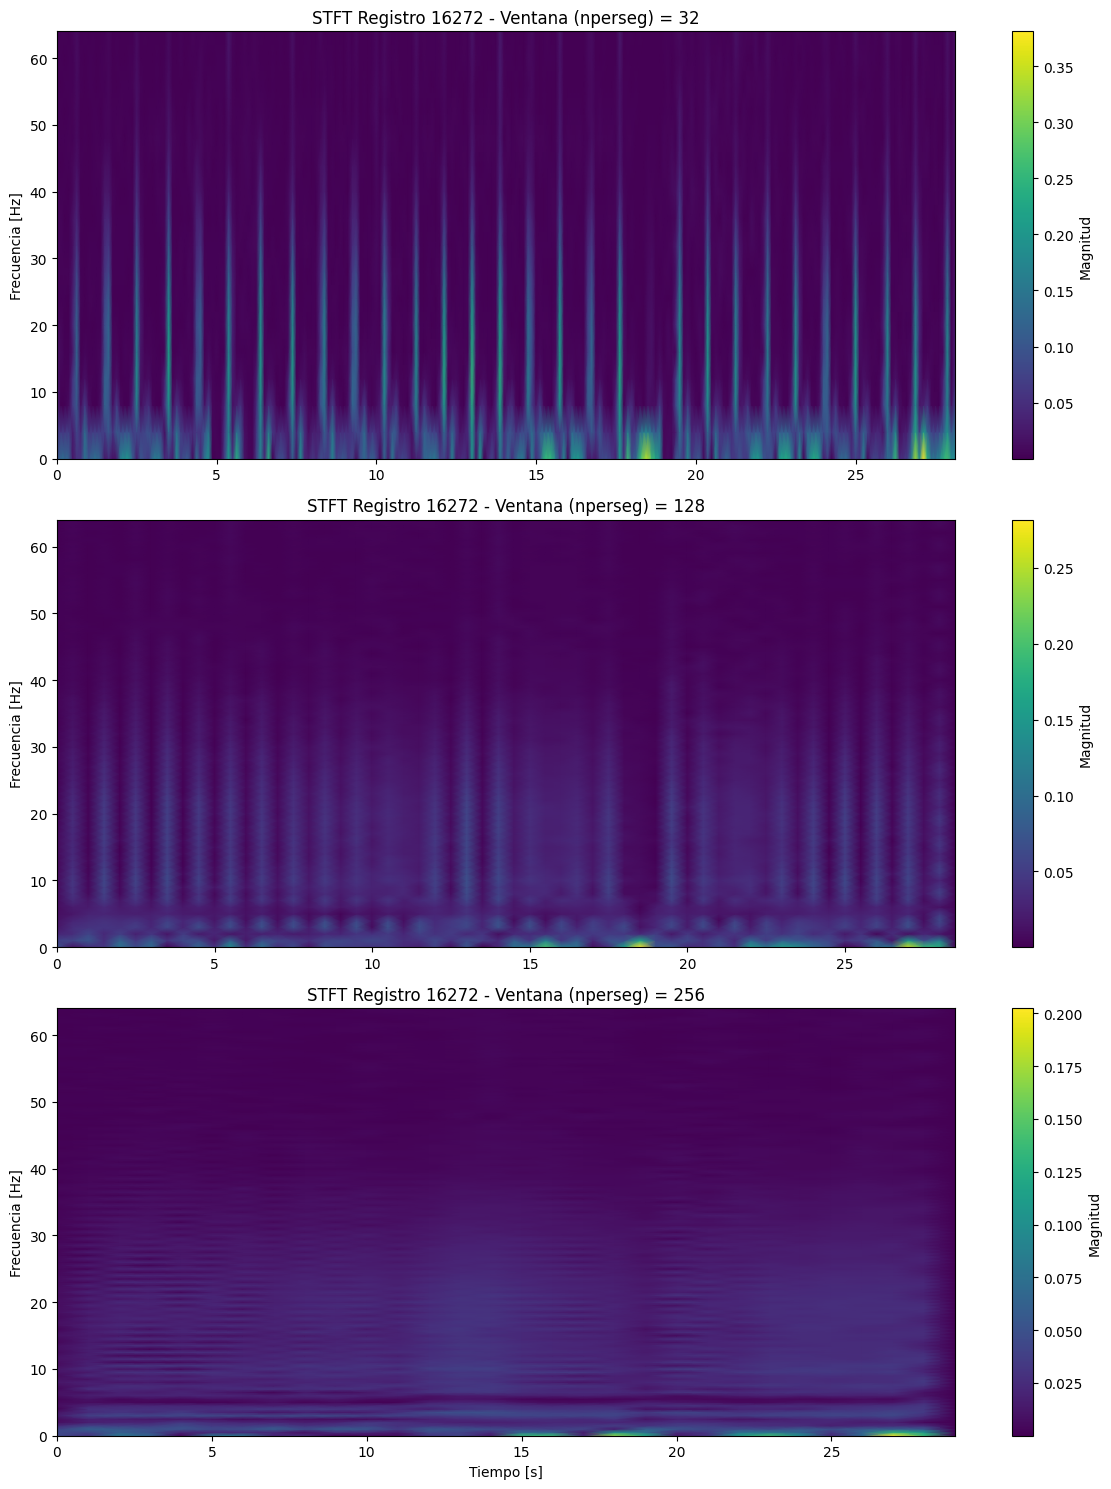

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import wfdb
from scipy import signal

# --- CONFIGURACIÓN DEL EJERCICIO 2.2 ---
RECORD_NAME = "16272"          # Seleccionamos el registro 16272 solicitado
FS = 128                       # Frecuencia de muestreo (conocida por el análisis previo)
VENTANAS = [32, 128, 256]      # Tamaños de ventana a comparar

# 1. Cargar la señal (10 segundos iniciales)
# Leemos el registro desde la base de datos nsrdb en PhysioNet
record = wfdb.rdrecord(RECORD_NAME, pn_dir="nsrdb", sampto=3600)
x = record.p_signal[:, 0]      # Extraemos el primer canal (ECG1)
x_ac = x - np.mean(x)          # Eliminamos la componente DC para centrar el espectro

# 2. Generar Comparativa de STFT
# Creamos una figura con 3 sub-gráficas para comparar visualmente los efectos
fig, axs = plt.subplots(len(VENTANAS), 1, figsize=(12, 15))

for i, nperseg in enumerate(VENTANAS):
    # Calculamos la STFT para el tamaño de ventana actual
    f, t, zxx = signal.stft(x_ac, fs=FS, nperseg=nperseg)

    # Graficamos el espectrograma
    im = axs[i].pcolormesh(t, f, np.abs(zxx), shading='gouraud', cmap='viridis')
    axs[i].set_title(f"STFT Registro {RECORD_NAME} - Ventana (nperseg) = {nperseg}")
    axs[i].set_ylabel("Frecuencia [Hz]")
    fig.colorbar(im, ax=axs[i], label="Magnitud")

axs[-1].set_xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

# --- RESPUESTAS DEL EJERCICIO 2.2 ---
# 1. ¿Cuál permite observar mejor los eventos temporales?
# Respuesta: A menor ventana mejor resolución temporal, por lo tanto nperseg = 32
# es la que permite observar mejor los latidos individuales (líneas verticales).

# 2. ¿Cuál proporciona mayor detalle en frecuencia?
# Respuesta: A mayor ventana mejor resolución frecuencial, por lo tanto nperseg = 256
# es la que define bandas horizontales más estrechas y precisas.

# 3. ¿Cuál considera más apropiada para este registro? Justifique.
# Respuesta: La de 32 muestras. En ECG nos interesa identificar eventos rápidos
# (como el complejo QRS), por lo que priorizar la localización temporal es clave
# para detectar arritmias o cambios súbitos en el ritmo.

In [51]:
# --- RESPUESTA AL EJERCICIO 2.3 ---

# Ejercicio 2.3 — Comparación FFT vs. STFT
# Explique con sus propias palabras:
# ¿Por qué una FFT global puede ocultar cuándo ocurre un determinado evento,
# mientras que una STFT puede localizarlo temporalmente?

# La FFT toma toda la señal y hace un promedio de cada frecuencia,
# lo junta todo dejando de lado el tiempo, mientras que las STFT corta en ventanas la señal y luego aplica
# la transformada a cada una, permitiendo ubicar los instantes o intervalos de tiempo.

# 15. Preguntas conceptuales

Responda con sus propias palabras.

### 1.
¿Qué es PhysioNet?

Es una base de datos de acceso libre que provee señales fisiologicas.

### 2.
¿Qué información proporciona `record.p_signal`?

Los datos de la señal en forma de matriz.

### 3.
¿Qué representa la frecuencia de muestreo `fs`?

La cantidad de muestras que se toman en la señal por cada segundo de tiempo

### 4.
¿Qué representa la componente DC de una señal?

Representa el offset de la señal ubicado en 0 Hz.

### 5.
¿Por qué se resta la media antes de analizar el espectro AC?

Para eliminar la señal DC.

### 6.
¿Qué información proporciona la FFT?

El espectro de frecuencias de la señal que incluye la frecuencia y magnitud, nos permite distiguir los componentes frecuenciales

### 7.
¿Qué información adicional proporciona la STFT?

Añade la información temporal de la señal.

### 8.
¿Qué relación existe entre `fs`, número de muestras y duración?

t (duración) = N(número de muestros)/fs (sampling frequency o frecuencia de muestreo)

### 9.
¿Qué efecto tiene aumentar el tamaño de ventana de la STFT?
Aumeta la resolución frecuencial pero disminuye la resolución temporal

### 10.
¿Por qué no es suficiente utilizar únicamente una representación temporal para analizar completamente una señal biomédica?
Por que no nos permite identificar los componentes frecuenciales deseados de la señal ya sean los que queremos filtrar o amplificar como ruido o artefactos.


# 16. Reto final

Seleccione uno de los tres registros y realice un análisis completo:

```text
PhysioNet
   ↓
Seleccionar registro
   ↓
Cargar señal
   ↓
Identificar fs y canales
   ↓
Representar en el tiempo
   ↓
Calcular FFT
   ↓
Eliminar componente DC
   ↓
Comparar espectros
   ↓
Calcular STFT
   ↓
Analizar espectrograma
   ↓
Interpretar resultados
```

### Entregable

El informe debe incluir:

1. Registro seleccionado.
2. Frecuencia de muestreo.
3. Canal analizado.
4. Gráfica temporal.
5. FFT con DC.
6. FFT sin DC.
7. Espectrograma STFT.
8. Comparación de resultados.
9. Respuestas a las preguntas de análisis.
10. Conclusiones.


In [52]:
# 1 y 2) Registro seleccionado y frecuencia de muestreo
import numpy as np
import matplotlib.pyplot as plt
import wfdb
from scipy import signal

# Seleccionamos el registro 16420 de PhysioNet
NOMBRE_REGISTRO = '16420'
DB = 'nsrdb'
PUNTOS = 3600

# Carga de la señal y metadatos
registro = wfdb.rdrecord(NOMBRE_REGISTRO, pn_dir=DB, sampto=PUNTOS)
fs = registro.fs                                  # Frecuencia de muestreo

print(f"Registro {NOMBRE_REGISTRO} cargado con éxito.")
print(f"Frecuencia de muestreo es {fs}.")


Registro 16420 cargado con éxito.
Frecuencia de muestreo es 128.


Nombre del canal ECG1.


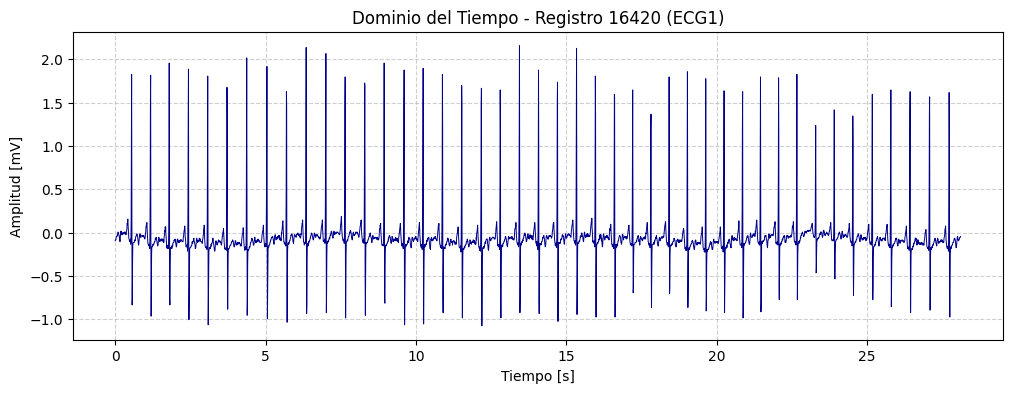

In [53]:
# 3 y 4) Canal analizado y grafica temporal

canal_nombre = registro.sig_name[0]               # Nombre del canal
unidades = registro.units[0]                      # Unidades (mV)
x = registro.p_signal[:, 0]                       # Datos de la señal
tiempo = np.arange(len(x)) / fs                   # Vector de tiempo
print(f"Nombre del canal {canal_nombre}.")

plt.figure(figsize=(12, 4))
plt.plot(tiempo, x, color='darkblue', linewidth=0.7)
plt.title(f"Dominio del Tiempo - Registro {NOMBRE_REGISTRO} ({canal_nombre})")
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{unidades}]")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

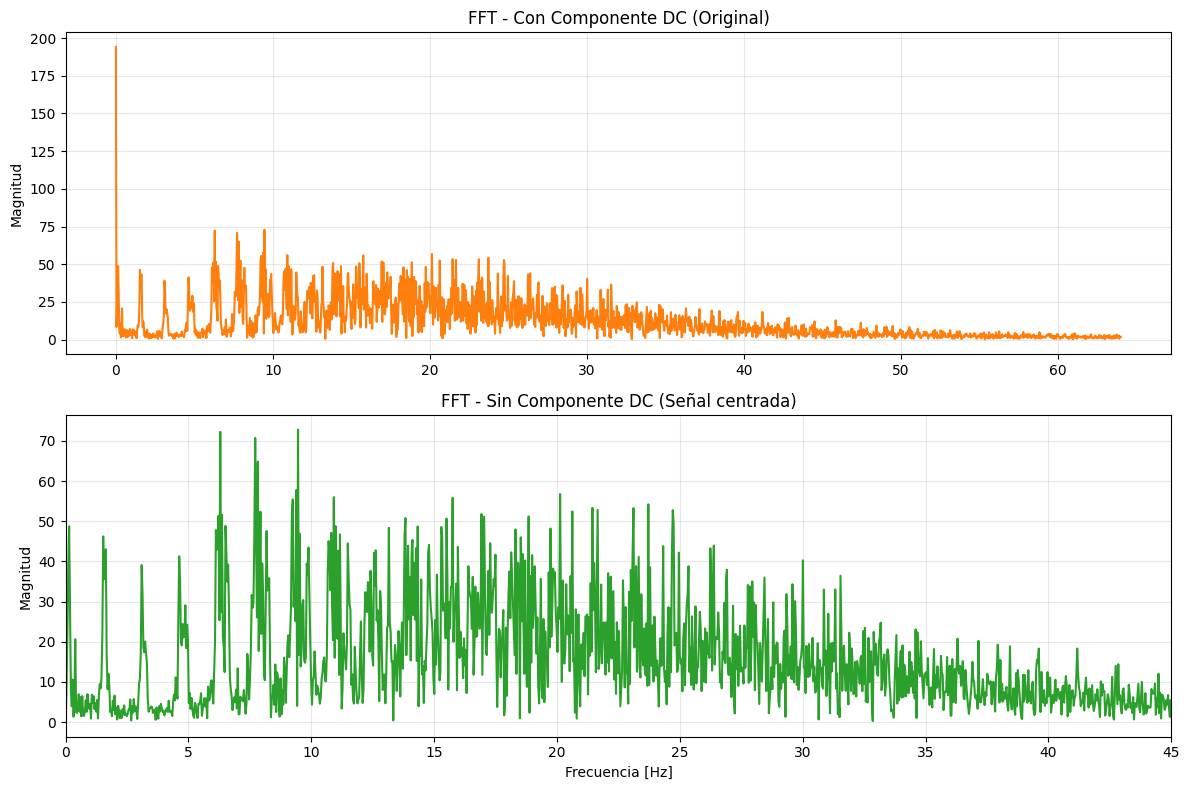

In [54]:
# 5 y 6) FFT con DC y sin DC
x_sin_dc = x - np.mean(x)                         # Restamos la media para eliminar DC
freqs = np.fft.rfftfreq(len(x), d=1/fs)           # Eje de frecuencia
mag_con_dc = np.abs(np.fft.rfft(x))               # Magnitud original
mag_sin_dc = np.abs(np.fft.rfft(x_sin_dc))        # Magnitud sin offset

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Comparativa visual
ax1.plot(freqs, mag_con_dc, color='tab:orange')
ax1.set_title("FFT - Con Componente DC (Original)")
ax1.set_ylabel("Magnitud")
ax1.grid(True, alpha=0.3)

ax2.plot(freqs, mag_sin_dc, color='tab:green')
ax2.set_title("FFT - Sin Componente DC (Señal centrada)")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Magnitud")
ax2.set_xlim(0, 45)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

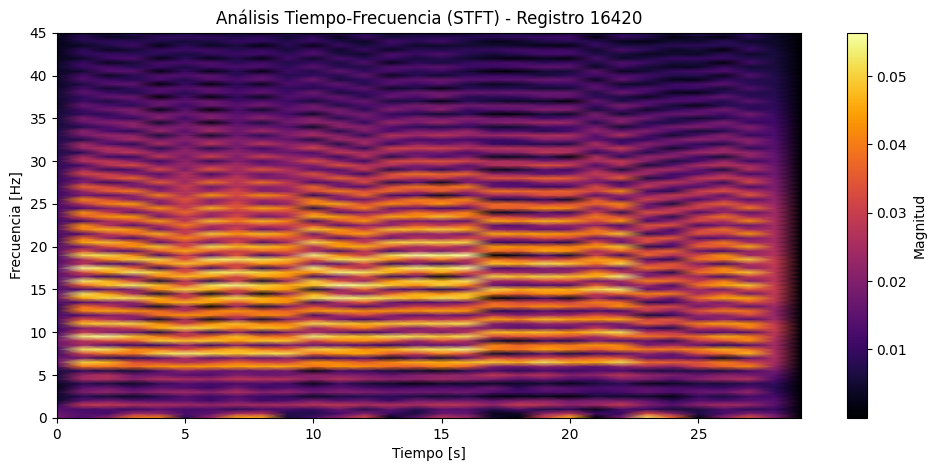

In [55]:
# 7) Calculo del espectrograma
# Usamos una ventana de 256 muestras para observar la evolución temporal
f_stft, t_stft, zxx = signal.stft(x_sin_dc, fs=fs, nperseg=256)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t_stft, f_stft, np.abs(zxx), shading='gouraud', cmap='inferno')
plt.title(f"Análisis Tiempo-Frecuencia (STFT) - Registro {NOMBRE_REGISTRO}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.colorbar(label="Magnitud")
plt.ylim(0, 45)
plt.show()

In [56]:
# 8) Interpretacion de los datos
# Conclusiones del análisis del registro 16420:
# 1 - El ritmo es constante pero la señal tiene baja amplitud comparada con otros registros.
# 2 - La componente DC dominaba el espectro, ocultando los picos de ~10 Hz que surgieron tras la resta.
# 3 - El espectrograma muestra una pérdida de potencia en las altas frecuencias hacia el final del tramo (s. 23-28).

### Informe Final - Reto Final (Registro 16420)

**1. Registro seleccionado**

Se ha seleccionado el registro **16420** de la base de datos *Normal Sinus Rhythm Database (nsrdb)* de PhysioNet.

**2. Frecuencia de muestreo**

La frecuencia de muestreo ($f_s$) es de **128 Hz**.

**3. Canal analizado**

El análisis se realizó sobre el **Canal 0**, que corresponde a la señal **ECG1**.

**4. Gráfica temporal**

La señal en el tiempo muestra un ritmo sinusal rítmico con una amplitud que oscila entre -1.0 mV y 2.1 mV. Es una señal de morfología clara pero con menor amplitud pico a pico en comparación con otros registros analizados previamente.

**5. FFT con DC**

En el espectro de magnitud original, destaca un pico prominente en **0 Hz** con una magnitud de **194.1**. Este componente representa el nivel de offset (DC) de la señal y dificulta la observación detallada de las frecuencias fisiológicas bajas.

**6. FFT sin DC**

Tras eliminar la media, el pico en 0 Hz desaparece, revelando una frecuencia dominante en **9.458 Hz** con una magnitud de **72.8**. El grueso de la energía del ECG se distribuye principalmente entre los 0.5 y 35 Hz.

**7. Espectrograma STFT**

Utilizando una ventana de 256 muestras ($nperseg$), el espectrograma muestra bandas de energía horizontales estables. Se observa una **pérdida de intensidad/potencia** en las frecuencias superiores a partir del segundo 23 del registro.

**8. Comparación de resultados**

Al comparar el dominio temporal con el frecuencial, se confirma que la regularidad de los latidos en el tiempo se traduce en picos espectrales definidos en la FFT. La STFT complementa esto al mostrar que, aunque el ritmo parece constante en el tiempo, existe una dinámica de energía no estacionaria al final del tramo.

**9. Respuestas a las preguntas de análisis**

- *¿Por qué el espectro cambia al quitar DC?* Porque eliminamos el valor promedio que no contiene información de la variabilidad cardiaca.
- *¿Qué aporta la STFT aquí?* Identifica el momento exacto (s. 23) donde la señal pierde potencia, algo que la FFT global promedia y oculta.
- *¿Resolución utilizada?* Se eligió 256 muestras para priorizar la resolución en frecuencia y definir mejor las bandas del ECG.

**10. Conclusiones**
1. El registro 16420 presenta un comportamiento rítmico pero con una atenuación de energía en altas frecuencias hacia el final del segmento.
2. La eliminación de la componente DC es vital para el análisis espectral biomédico, permitiendo ajustar la escala a las magnitudes de interés fisiológico.
3. El uso conjunto de FFT y STFT permite una comprensión total: qué frecuencias están presentes y en qué momento ocurren los cambios de energía.

# 17. Conclusiones esperadas

Al finalizar este ejercicio, el estudiante debe comprender que una señal biomédica puede estudiarse desde tres perspectivas complementarias:

```text
                    SEÑAL BIOMÉDICA
                           │
             ┌─────────────┼─────────────┐
             ↓             ↓             ↓
          TIEMPO       FRECUENCIA    TIEMPO-FRECUENCIA
             │             │             │
           x(t)           FFT           STFT
             │             │             │
             └─────────────┼─────────────┘
                           ↓
                  INTERPRETACIÓN
                     DE LA SEÑAL
```

La representación temporal permite observar la evolución de la amplitud; la FFT permite estudiar el contenido frecuencial global; y la STFT permite analizar cómo cambia dicho contenido con el tiempo.


# Referencias

- PhysioNet — plataforma para el acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas para lectura y procesamiento de registros fisiológicos.
- Normal Sinus Rhythm Database (NSRDB) — base de datos utilizada en este ejercicio.

> Consulte siempre la documentación de la base de datos para interpretar correctamente sus registros, canales y anotaciones.
